<a href="https://colab.research.google.com/github/fataa34/applied-optimization-with-python/blob/unconstraint/Unconstraint_Metode_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unconstraint Metode Gradient

## 6.3 TEKNIK NUMERIK—METODE BERBASIS GRADIEN

Berdasarkan definisi sebelumnya, ini akan disebut sebagai *metode orde pertama*. Arah pencarian (search directions) akan dibangun menggunakan gradien dari fungsi objektif. Karena gradien dihitung, kondisi Kuhn-Tucker (FOC) untuk masalah tak terkendala (unconstrained problems), $\nabla f = 0$, dapat digunakan untuk memeriksa konvergensi. SOC (Kondisi Orde Kedua) hampir tidak pernah diterapkan. Salah satu alasannya adalah metode ini akan melibatkan komputasi matriks turunan kedua (second derivative matrix) berukuran $n \times n$ yang dianggap mahal secara komputasi, terutama jika evaluasi fungsi objektif memerlukan pemanggilan metode elemen hingga (finite element method) untuk menghasilkan informasi yang diperlukan. Alasan lain untuk tidak menghitung Hessian adalah bahwa keberadaan turunan kedua dalam masalah desain nyata tidaklah pasti, meskipun secara komputasi mungkin atau layak dilakukan. Untuk masalah yang dapat dijelaskan dengan perhitungan simbolis, MATLAB seharusnya dapat menangani komputasi turunan kedua pada solusi yang mungkin dan nilai eigen-nya (eigenvalues).

Tanpa SOC, metode-metode ini memerlukan kewaspadaan pengguna untuk memastikan bahwa solusi yang diperoleh adalah minimum, bukan maksimum atau titik pelana (saddle point). Cara sederhana untuk memverifikasi ini adalah dengan mengganggu (perturb) fungsi objektif melalui gangguan pada variabel desain di titik solusi dan memverifikasi bahwa itu adalah minimum lokal. Ini memunculkan sifat penting dari metode-metode ini—mereka hanya menemukan **optimum lokal**. Biasanya ini akan dekat dengan desain tempat iterasi dimulai. Sebelum mengakhiri eksplorasi desain, penting untuk menjalankan metode dari beberapa titik awal yang berbeda untuk menemukan apakah ada nilai minimum lain dan memilih yang terbaik dengan perbandingan langsung (head to head). Sebagian besar metode optimasi tak terkendala dan terkendala (constrained) yang ada termasuk dalam kategori ini.

Empat metode disajikan. Yang pertama adalah *metode Penurunan Tercuram (Steepest Descent)*. Meskipun metode ini tidak digunakan dalam praktik, ia memberikan contoh yang sangat baik untuk memahami prinsip-prinsip algoritmik metode berbasis gradien. Yang kedua adalah *teknik Gradien Konyugasi (Conjugate Gradient)* yang merupakan pekerja keras klasik (classical workhorse) terutama dalam penggunaan industri. Yang ketiga dan keempat termasuk dalam kategori *metode Metrik Variabel (Variable Metric methods)*, atau juga disebut *metode Kuasi-Newton (Quasi-Newton)*. Metode-metode ini telah populer selama beberapa waktu, dan kemungkinan akan tetap demikian untuk waktu yang lama.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
def fungsi_objektif(x):
  return 3 + (x[0] - 1.5*x[1])**2 + (x[1]-2)**2

def gradien(x):
  return [2*x[0]-3*x[1],-3*x[0]+(13/2)*x[1]-4]

In [ ]:
def golden_section(fu_ob,a, b, epsilon, max_iter):
  tau = 0.38197
  results = []
  x1 = (1 - tau) * a + tau * b
  x2 = tau * a + (1 - tau) * b
  f1 = fu_ob(x1)
  f2 = fu_ob(x2)
  for i in range(max_iter):
    if abs(b - a) < epsilon:
      break
    elif f1 > f2:
      a = x1
      x1 = x2
      f1 = f2
      x2 = tau * a + (1 - tau) * b
      f2 = fu_ob(x2)
    else:
      b = x2
      x2 = x1
      f2 = f1
      x1 = (1 - tau) * a + tau * b
      f1 = fu_ob(x1)
  return (a + b) / 2

## Steepest Descent

In [ ]:
def steepest_descent(x0, max_iter, epsilon1, epsilon2, epsilon3):

  x_j = np.array(x0, dtype=float)
  f_i = fungsi_objektif(x_j)

  gradien_val = np.array(gradien(x_j))
  results = []

  results.append([0, x_j, f_i, gradien_val])

  for i in range(max_iter):

    s_i = -gradien_val

    def g(alpha):
      return fungsi_objektif(x_j + alpha * s_i)

    alpha = golden_section(g, 0, 10, 1e-6, 100)

    x_i = x_j + alpha*s_i
    fungsi_i = fungsi_objektif(x_i)

    gradien_i = np.array(gradien(x_i))

    delta_f = abs(fungsi_i - f_i)
    vektor_x = x_i - x_j
    delta_x = vektor_x.T @ vektor_x
    delta_g = gradien_i.T @ gradien_i

    results.append([i+1, x_i, fungsi_i, gradien_i])

    if delta_f < epsilon1 or delta_x < epsilon2 or delta_g < epsilon3:
      break

    x_j = x_i
    f_i = fungsi_i
    gradien_val = gradien_i

  return pd.DataFrame(results, columns=['iterasi', 'x', 'f(x)', 'gradien'])

In [ ]:
steepest_descent([0.5, 0.5], 100, 1e-4, 1e-4, 1e-4)

,iterasi,x,f(x),gradien
0,0,"[0.5, 0.5]",5.312500,"[-0.5, -2.25]"
1,1,"[0.5996483881513462, 0.9484177466810579]",4.783118,"[-1.6459564637404813, 0.36577018897283775]"
2,2,"[1.0723033034771903, 0.8433827220578713]",4.374924,"[-0.3855415592192335, -1.734922217055407]"
3,3,"[1.1491405455736388, 1.1891473620109667]",4.060174,"[-1.2691609948856226, 0.2820362163503676]"
4,4,"[1.5135954580352493, 1.1081572551961567]",3.817477,"[-0.2972808495179713, -1.3377642153307292]"
5,5,"[1.5728425730007067, 1.3747693507646719]",3.630339,"[-0.978622906292602, 0.21747306096824737]"
6,6,"[1.8538651499031975, 1.3123195147683986]",3.486041,"[-0.22922824449880075, -1.0315186037150017]"
7,7,"[1.899549631113387, 1.517897986882141]",3.374776,"[-0.7545946984196488, 0.16768802139375438]"
8,8,"[2.116240615050624, 1.4697443456938304]",3.288981,"[-0.17675180698024295, -0.7953835981419752]"
9,9,"[2.1514666803874625, 1.6282617327275621]",3.222827,"[-0.5818518374077613, 0.1293012215667666]"


In [ ]:
steepest_descent_results = steepest_descent([0.5, 0.5], 100, 1e-4, 1e-4, 1e-4)

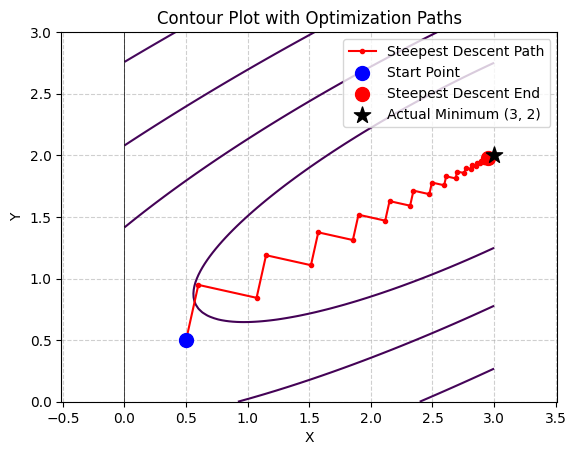

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(0, 3, 100)
y = np.linspace(0, 3, 100)
X, Y = np.meshgrid(x, y)
Z = 3 + (X - 1.5*Y)**2 + (Y-2)**2

# Plot the contour lines
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20))

# Extract the x values from the results DataFrames
steepest_descent_path = np.array(steepest_descent_results['x'].tolist())
# Plot the search paths
plt.plot(steepest_descent_path[:, 0], steepest_descent_path[:, 1], 'r-o', label='Steepest Descent Path', markersize=3)


# Mark the start point
plt.scatter([steepest_descent_path[0, 0]], [steepest_descent_path[0, 1]], c='blue', s=100, label='Start Point', zorder=5)

# Mark the end points (approximate minimums)
plt.scatter([steepest_descent_path[-1, 0]], [steepest_descent_path[-1, 1]], c='red', s=100, label='Steepest Descent End', zorder=5)

# Mark the actual minimum point
plt.scatter([3], [2], c='black', s=150, marker='*', label='Actual Minimum (3, 2)', zorder=5)

plt.title('Contour Plot with Optimization Paths')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
# Set aspect ratio to equal for correct representation
plt.axis('equal')
plt.show()

## Conjugate Gradient

In [ ]:
def conjugate_gradient(x0, max_iter, epsilon1, epsilon2, epsilon3):
  x_j = np.array(x0, dtype=float)
  x_b = x_j
  f_j = fungsi_objektif(x_j)
  gradien_j = np.array(gradien(x_j))

  results = []
  results.append([0, x_j, f_j, gradien_j])

  s_i = -gradien_j

  for i in range(max_iter):

    if i == 0:
      pass
    else:
      gradien_b = np.array(gradien(x_b))

      pembilang = gradien_j.T @ gradien_j
      penyebut = gradien_b.T @ gradien_b

      if abs(penyebut) < 1e-10:
        beta = 0
      else:
        beta = pembilang / penyebut
      s_i = -gradien_j + beta * s_i

    x_b = x_j

    def g(alpha):
      return fungsi_objektif(x_j + alpha * s_i)

    alpha = golden_section(g, 0, 10, 1e-6, 100)

    x_i_baru = x_j + alpha*s_i
    f_i_baru = fungsi_objektif(x_i_baru)
    gradien_i_baru = np.array(gradien(x_i_baru))

    delta_f = abs(f_i_baru - f_j)

    delta_x_vec = x_i_baru - x_j
    delta_x_sq = delta_x_vec.T @ delta_x_vec

    delta_g_sq = gradien_i_baru.T @ gradien_i_baru

    results.append([i+1, x_i_baru, f_i_baru, gradien_i_baru])

    if delta_f < epsilon1 or delta_x_sq < epsilon2 or delta_g_sq < epsilon3:
      break

    x_j = x_i_baru
    f_j = f_i_baru
    gradien_j = gradien_i_baru

  return pd.DataFrame(results, columns=['iterasi', 'x', 'f(x)', 'gradien'])

In [ ]:
conjugate_gradient([0.5, 0.5], 100, 1e-4, 1e-4, 1e-4)

,iterasi,x,f(x),gradien
0,0,"[0.5, 0.5]",5.312500,"[-0.5, -2.25]"
1,1,"[0.5996483881513462, 0.9484177466810579]",4.783118,"[-1.6459564637404813, 0.36577018897283775]"
2,2,"[3.0000002842217297, 1.9999994358479538]",3.000000,"[2.2608995982054125e-06, -4.519653488799236e-06]"


In [ ]:
conjugate_gradient_results = conjugate_gradient([0.5, 0.5], 100, 1e-4, 1e-4, 1e-4)

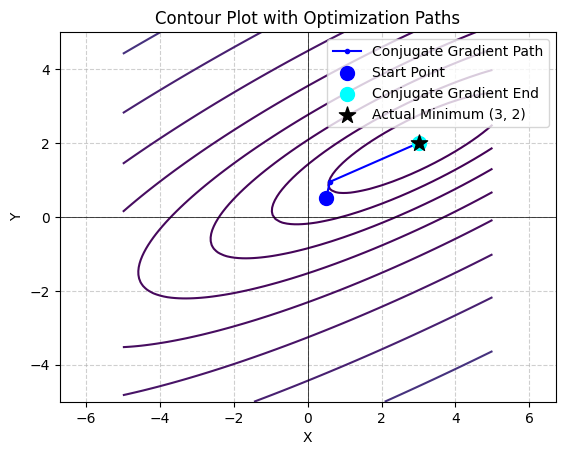

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = 3 + (X - 1.5*Y)**2 + (Y-2)**2

# Plot the contour lines
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20))

# Extract the x values from the results DataFrames
conjugate_gradient_path = np.array(conjugate_gradient_results['x'].tolist())


# Plot the search paths
plt.plot(conjugate_gradient_path[:, 0], conjugate_gradient_path[:, 1], 'b-o', label='Conjugate Gradient Path', markersize=3)

# Mark the start point
plt.scatter([conjugate_gradient_path[0, 0]], [conjugate_gradient_path[0, 1]], c='blue', s=100, label='Start Point', zorder=5)

# Mark the end points (approximate minimums)
plt.scatter([conjugate_gradient_path[-1, 0]], [conjugate_gradient_path[-1, 1]], c='cyan', s=100, label='Conjugate Gradient End', zorder=5)

# Mark the actual minimum point
plt.scatter([3], [2], c='black', s=150, marker='*', label='Actual Minimum (3, 2)', zorder=5)

plt.title('Contour Plot with Optimization Paths')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
# Set aspect ratio to equal for correct representation
plt.axis('equal')
plt.show()

## Davidson-Fletcher-Powell (DFP)

In [ ]:
def metode_dfp(x0, matriks_inisiasi, max_iter, epsilon1, epsilon2, epsilon3):
    x_j = np.array(x0, dtype=float)
    A_j = np.array(matriks_inisiasi, dtype=float)
    f_j = fungsi_objektif(x_j)
    gradien_j = np.array(gradien(x_j))

    results = []
    results.append([0, x_j, f_j, gradien_j])

    for i in range(max_iter):
        if gradien_j.ndim > 1:
            gradien_j = gradien_j.flatten()

        s_i = -A_j @ gradien_j

        def g(alpha):
            return fungsi_objektif(x_j + alpha * s_i)

        alpha = golden_section(g, 0, 10, 1e-6, 100)

        delta_x = alpha * s_i
        x_i = x_j + delta_x

        gradien_i = np.array(gradien(x_i))
        if gradien_i.ndim > 1:
            gradien_i = gradien_i.flatten()

        dot_gradien = gradien_i.T @ gradien_i
        delta_f = abs(fungsi_objektif(x_i) - f_j)
        dot_x = delta_x.T @ delta_x

        if delta_f < epsilon1 or dot_x < epsilon2 or dot_gradien < epsilon3:
            results.append([i + 1, x_i, fungsi_objektif(x_i), gradien_i])
            break

        Y = gradien_i - gradien_j

        if Y.ndim > 1: Y = Y.flatten()
        if delta_x.ndim > 1: delta_x = delta_x.flatten()

        Z = A_j @ Y
        if Z.ndim > 1: Z = Z.flatten()

        denom_B = delta_x.T @ Y
        denom_C = Y.T @ Z

        if abs(denom_B) < 1e-10: denom_B = 1e-10
        if abs(denom_C) < 1e-10: denom_C = 1e-10

        B = np.outer(delta_x, delta_x) / denom_B
        C = np.outer(Z, Z) / denom_C

        A_j = A_j + B - C

        x_j = x_i
        f_j = fungsi_objektif(x_i)
        gradien_j = gradien_i

        results.append([i + 1, x_i, f_j, gradien_i])

    return pd.DataFrame(results, columns=['iterasi', 'x', 'f(x)', 'gradien'])

In [ ]:
metode_dfp([0.5, 0.5], [[1,0],[0,1]], 100, 1e-4, 1e-4, 1e-4)

,iterasi,x,f(x),gradien
0,0,"[0.5, 0.5]",5.312500,"[-0.5, -2.25]"
1,1,"[0.5996483881513462, 0.9484177466810579]",4.783118,"[-1.6459564637404813, 0.36577018897283775]"
2,2,"[2.999999917563159, 1.9999996328660679]",3.000000,"[9.365281146145321e-07, -2.1390600366544277e-06]"


In [ ]:
dfp_results = metode_dfp([0.5, 0.5], [[1,0],[0,1]], 100, 1e-4, 1e-4, 1e-4)

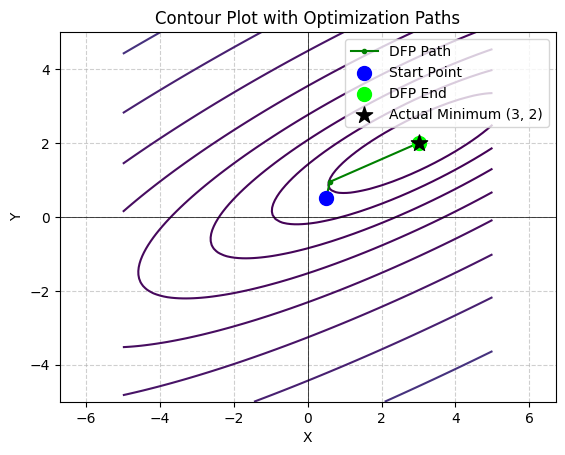

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = 3 + (X - 1.5*Y)**2 + (Y-2)**2

# Plot the contour lines
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20))

# Extract the x values from the results DataFrames
dfp_path = np.array(dfp_results['x'].tolist())


# Plot the search paths
plt.plot(dfp_path[:, 0], dfp_path[:, 1], 'g-o', label='DFP Path', markersize=3)

# Mark the start point
plt.scatter([dfp_path[0, 0]], [dfp_path[0, 1]], c='blue', s=100, label='Start Point', zorder=5)

# Mark the end points (approximate minimums)
plt.scatter([dfp_path[-1, 0]], [dfp_path[-1, 1]], c='lime', s=100, label='DFP End', zorder=5)

# Mark the actual minimum point
plt.scatter([3], [2], c='black', s=150, marker='*', label='Actual Minimum (3, 2)', zorder=5)

plt.title('Contour Plot with Optimization Paths')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
# Set aspect ratio to equal for correct representation
plt.axis('equal')
plt.show()

## Byordon Fletcher Goldfrab Shanno (BFGS)

In [ ]:
def metode_bfgs(x0, matriks_inisiasi, max_iter, epsilon1, epsilon2, epsilon3):
    x_j = np.array(x0, dtype=float)
    A_j = np.array(matriks_inisiasi, dtype=float)
    f_j = fungsi_objektif(x_j)
    gradien_j = np.array(gradien(x_j))

    results = []
    results.append([0, x_j, f_j, gradien_j])

    for i in range(max_iter):
        if gradien_j.ndim > 1:
            gradien_j = gradien_j.flatten()

        # Step 2: Tentukan arah pencarian
        s_i = -A_j @ gradien_j

        def g(alpha):
            return fungsi_objektif(x_j + alpha * s_i)

        # Tentukan alpha_i (alpha)
        alpha = golden_section(g, 0, 10, 1e-6, 100)

        # Tentukan X_i+1 dan Delta X
        delta_x = alpha * s_i
        x_i = x_j + delta_x

        gradien_i = np.array(gradien(x_i))
        if gradien_i.ndim > 1:
            gradien_i = gradien_i.flatten()

        # Step 3: Cek kriteria berhenti
        dot_gradien = gradien_i.T @ gradien_i
        delta_f = abs(fungsi_objektif(x_i) - f_j)
        dot_x = delta_x.T @ delta_x

        if delta_f < epsilon1 or dot_x < epsilon2 or dot_gradien < epsilon3:
            results.append([i + 1, x_i, fungsi_objektif(x_i), gradien_i])
            break

        # Tentukan Y
        Y = gradien_i - gradien_j

        if Y.ndim > 1: Y = Y.flatten()
        if delta_x.ndim > 1: delta_x = delta_x.flatten()

        # Tentukan [B]
        denom_B = Y.T @  delta_x
        if abs(denom_B) < 1e-10: denom_B = 1e-10
        B = np.outer(Y, Y) / denom_B

        # Tentukan [C]
        denom_C = gradien_j.T @ s_i
        if abs(denom_C) < 1e-10: denom_C = 1e-10
        C = np.outer(gradien_j, gradien_j) / denom_C

        # === PERBAIKAN: Sesuaikan dengan rumus di gambar ===
        # Rumus gambar: [A_i+1] = [A_i] + [B] + [C]
        A_j = A_j + B + C
        # ===============================================

        # Siapkan untuk iterasi berikutnya
        x_j = x_i
        f_j = fungsi_objektif(x_i)
        gradien_j = gradien_i

        results.append([i + 1, x_i, f_j, gradien_i])

    return pd.DataFrame(results, columns=['iterasi', 'x', 'f(x)', 'gradien'])

In [ ]:
def metode_bfgs_fiks(x0, matriks_inisiasi, max_iter, epsilon1, epsilon2, epsilon3):
    x_j = np.array(x0, dtype=float)
    A_j = np.array(matriks_inisiasi, dtype=float)
    f_j = fungsi_objektif(x_j)
    gradien_j = np.array(gradien(x_j))

    results = []
    results.append([0, x_j, f_j, gradien_j])

    for i in range(max_iter):
        if gradien_j.ndim > 1:
            gradien_j = gradien_j.flatten()

        s_i = -A_j @ gradien_j

        def g(alpha):
            return fungsi_objektif(x_j + alpha * s_i)

        alpha = golden_section(g, 0, 10, 1e-6, 100)

        delta_x = alpha * s_i
        x_i = x_j + delta_x

        gradien_i = np.array(gradien(x_i))
        if gradien_i.ndim > 1:
            gradien_i = gradien_i.flatten()

        dot_gradien = gradien_i.T @ gradien_i
        delta_f = abs(fungsi_objektif(x_i) - f_j)
        dot_x = delta_x.T @ delta_x

        if delta_f < epsilon1 or dot_x < epsilon2 or dot_gradien < epsilon3:
            results.append([i + 1, x_i, fungsi_objektif(x_i), gradien_i])
            break

        Y = gradien_i - gradien_j

        if Y.ndim > 1: Y = Y.flatten()
        if delta_x.ndim > 1: delta_x = delta_x.flatten()

        sk = delta_x
        yk = Y
        Ak = A_j

        sk_T_yk = sk.T @ yk
        if abs(sk_T_yk) < 1e-10: sk_T_yk = 1e-10

        Z = Ak @ yk
        if Z.ndim > 1: Z = Z.flatten()

        yk_T_Z = yk.T @ Z

        koefisien1 = (sk_T_yk + yk_T_Z) / (sk_T_yk**2)
        Term1 = koefisien1 * np.outer(sk, sk)

        Term2_A = np.outer(Z, sk)
        Term2_B = np.outer(sk, Z)
        Term2 = -(Term2_A + Term2_B) / sk_T_yk

        A_j = Ak + Term1 + Term2

        x_j = x_i
        f_j = fungsi_objektif(x_i)
        gradien_j = gradien_i

        results.append([i + 1, x_i, f_j, gradien_i])

    return pd.DataFrame(results, columns=['iterasi', 'x', 'f(x)', 'gradien'])

In [ ]:
metode_bfgs_fiks([0.5, 0.5], [[1,0],[0,1]], 100, 1e-4, 1e-4, 1e-4)

,iterasi,x,f(x),gradien
0,0,"[0.5, 0.5]",5.312500,"[-0.5, -2.25]"
1,1,"[0.5996483881513462, 0.9484177466810579]",4.783118,"[-1.6459564637404813, 0.36577018897283775]"
2,2,"[2.9999996494416457, 1.999999755447984]",3.000000,"[3.2539339223092156e-08, -5.379130403326826e-07]"


In [ ]:
bfgs_results_fiks = metode_bfgs_fiks([0.5, 0.5], [[1,0],[0,1]], 100, 1e-4, 1e-4, 1e-4)

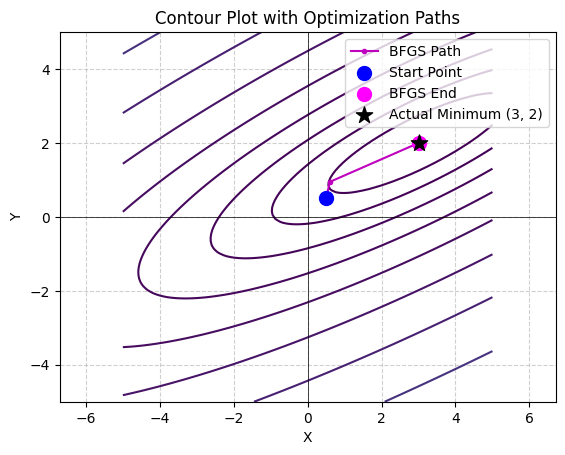

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = 3 + (X - 1.5*Y)**2 + (Y-2)**2

# Plot the contour lines
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20))

# Extract the x values from the results DataFrames
bfgs_path = np.array(bfgs_results_fiks['x'].tolist())


# Plot the search paths
plt.plot(bfgs_path[:, 0], bfgs_path[:, 1], 'm-o', label='BFGS Path', markersize=3)

# Mark the start point
plt.scatter([bfgs_path[0, 0]], [bfgs_path[0, 1]], c='blue', s=100, label='Start Point', zorder=5)

# Mark the end points (approximate minimums)
plt.scatter([bfgs_path[-1, 0]], [bfgs_path[-1, 1]], c='magenta', s=100, label='BFGS End', zorder=5)


# Mark the actual minimum point
plt.scatter([3], [2], c='black', s=150, marker='*', label='Actual Minimum (3, 2)', zorder=5)

plt.title('Contour Plot with Optimization Paths')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
# Set aspect ratio to equal for correct representation
plt.axis('equal')
plt.show()